<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <p style=" text-align: center; font-size: 32px;">   
   <strong> Optimal Trading Practical Assignment 1: Intraday Curves and Relationships Between Daily Variables </strong></p>
    <p style=" text-align: center; font-size: 25px;"><strong> Master Probabilities & Finance - Ecole Polytechnique and Sorbonne University <strong></p>
  <p style=" text-align: center; font-size: 20px;"> Constantin GLEYZE - based from an original Latex of S. Laruelle</p>
</header>

The objective of this lab is to familiarize yourself with the `Pandas` library and databases.

You will start by constructing average intraday curves of various market indicators such as volume, number of trades, turnover, volatility, spread, imbalance, and the liquidity available at the best bid and best ask prices.

You will then study the relationships between certain daily indicators, such as the links between volume and number of trades, turnover and number of trades, and finally spread and volatility per trade

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">I. Importing and Reading the Data</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

You have 10 databases in the form of `Pandas` DataFrames, one for each asset across 3 different exchanges:
* **Paris**: Bouygues, LVMH, Sanofi, and Total;
* **Nasdaq**: Amazon, Apple, Google;
* **Tokyo**: Canon, Panasonic, and Sony.

You will need to import the standard Python libraries: `NumPy`, `Pandas`, `MatPlotLib`, and `DateTime` to handle dates and times.

Each `DataFrame` contains all the transactions for the year 2011 for the given asset and has the same format:
* The `Time` index is the timestamp of the transaction;
* The `TradedPrice` column represents the average price per share of the transaction;
* The `TradedQty` column represents the volume of the transaction;
* The `BidPrice` column represents the best bid price just before the transaction;
* The `AskPrice` column represents the best ask price just before the transaction;
* The `BidQty` column represents the volume at the best bid just before the transaction;
* The `AskQty` column represents the volume at the best ask just before the transaction;
* The `TradedSign` column represents the sign of the transaction (negative for Bid and positive fr Ask).


The `Time` index of the time series is in Python's `DateTime` format.  
You can therefore extract dates, but also the year, month, day, hour, minute, etc


In [1]:
# Import of all the requiered librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
pd.set_option('display.max_rows', None)

In [2]:
# We import all the data within a DataFrame structure
canon = pd.read_hdf("CANON.h5")
amazon = pd.read_hdf("AMAZON.h5")
apple = pd.read_hdf("APPLE.h5")
bouygues = pd.read_hdf("BOUYGUES.h5")
lvmh = pd.read_hdf("LVMH.h5")
sanofi = pd.read_hdf("SANOFI.h5")
sony = pd.read_hdf("SONY.h5")
total = pd.read_hdf("TOTAL.h5")
google = pd.read_hdf("GOOGLE.h5")
panasonic = pd.read_hdf("PANASONIC.h5")

# We create geographical list for each stock, as well as a list with their names
list_US = [[google, amazon, apple]]
list_US_name = [['Google', 'Amazon', 'Apple']]
list_FR = [[total, lvmh, bouygues, sanofi]]
list_FR_name = [['Total', 'LVMH', 'Bouygues', 'Sanofi']]
list_JP = [[sony, canon, panasonic]]
list_JP_name = [['Sony', 'Canon', 'Panasonic']]

# We also create a list that contains the above geographical lists
total_list = [list_US[0], list_FR[0], list_JP[0]]
total_list_name = [list_US_name[0], list_FR_name[0], list_JP_name[0]]
titles = ["US market", "FR market", "JP market"]

In [21]:
# We create a sub function that return a dataframe containing the column of the looked indicators filtered on the good times
def return_worked_column (df, period, data_type, condense = True): 

    """
    Extracts and processes a chosen market microstructure indicator at a given frequency.

    Parameters
    ----------
    df        : DataFrame
                Market data (must contain Bid/Ask prices, traded prices/quantities).
    period    : str
                Resampling frequency (e.g., "1min", "5min", "15s").
    data_type : str
                One of the supported indicators:
                - "Volume", "Nb_trades", "Turnover", "Averaged_Spread",
                - "Imbalance_signed", "Imbalance_unsigned",
                - "Best_limits", "Vol_RV", "Vol_std".
    condense  : bool, optional
                If True, average the result across all days (by time-of-day). Default = True.

    Returns
    -------
    result    : DataFrame
                Time-indexed indicator (by time or datetime, depending on condense).
    """
    
    if data_type == "Volume" : 
        result = df.resample(period).size() # Number of trade per period interval
    elif data_type == "Nb_trades" : 
        result = df['TradedQty'].resample(period).sum() # Quantity traded every period
    elif data_type == "Turnover" : 
        turnover = df['TradedQty']*df['TradedPrice']  
        result = turnover.resample(period).sum() # Turnover every period
    elif data_type == "Averaged_Spread" : 
        spread = df['AskPrice'] - df['BidPrice']
        result = spread.resample(period).mean() # Average spread every period
    elif data_type == "Imbalance_signed" : 
        result = (((df['AskQty'] - df['BidQty']).abs())/(df['AskQty'] + df['BidQty'])).resample(period).mean() # Signed imbalanced every period
    elif data_type == "Imbalance_unsigned" : 
        result = ((df['AskQty'] - df['BidQty'])/(df['AskQty'] + df['BidQty'])).resample(period).mean()  # Unsigned imbalanced every period
    elif data_type == "Best_limits" : 
        result = (df['AskQty'] + df['BidQty']).resample(period).mean() # Best limits every period
    elif data_type == "Vol_RV" : 
        log_price_diff = ((np.log(df['TradedPrice'])).diff())**2
        result = log_price_diff.resample(period).sum() # Volatility every period using the sum of the square log returns
    elif data_type == "Vol_std" : 
        result = df['TradedPrice'].resample(period).std() # Volatility every period using the std of the exchanged price 


    result = result.to_frame(name=data_type)
    # We determine the trading time interval 
    min_time = df.index.min().floor('min').strftime('%H:%M') 
    max_time = df.index.max().floor('min').strftime('%H:%M')

    # If we want to take the average on every day we have for every period 
    if condense : 
        result['daily']= result.index.strftime('%H:%M') 
        result = result.groupby('daily').mean()
        result = result[(result.index >= min_time) & (result.index <= max_time)] # Filter the additional time created by strftime and containing no trades

    # We do not groupby but only restrict to the trading day time interval --> used for the linear regression below
    else : 
        result.index = result.index.strftime('%H:%M')    
        result = result[(result.index >= min_time) & (result.index <= max_time)]
    
    return result

# Function to compute a specific indicator (averaged or not) and to plot it 
def resample_volume(dfs_list,period, data_type, titles, stock_names_list, mean=False):

    """
    Computes and plots intraday microstructure indicators across multiple datasets.

    Parameters
    ----------
    dfs_list         : list of list of DataFrame
                       Nested list where each sublist groups comparable assets.
    period           : str
                       Frequency for time aggregation (e.g., "1min").
    data_type        : str
                       Type of indicator to compute (same choices as in return_worked_column).
    titles           : list of str
                       Title per group of compared assets.
    stock_names_list : list of list of str
                       Asset names corresponding to each dataframe in dfs_list.
    mean             : bool, optional
                       If True, normalize each day's series by its total. Default = False.

    Returns
    -------
    None
        Shows a multi-subplot graph with one panel per group in dfs_list.
    """

    # The function can take list of dataframe and plot them on the same row with a maximum of three graphs for each row
    num_subplots = len(dfs_list)
    cols = 3 
    rows = (num_subplots // cols) + (num_subplots % cols > 0)  # Calcul dynamique du nombre de lignes
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), constrained_layout=True)

    if rows == 1 : 
        axes = np.array([axes])
    axes = axes.flatten()

    # We loop on all the list of dataframe given
    for idx,(dfs, stock_names,title) in enumerate(zip(dfs_list,stock_names_list, titles)):  
        
        ax = axes[idx]
        results = []
        x_ticks = None 

        # We loop on all the dataframe within a given sublist
        for df in dfs : 
            result = return_worked_column (df,period, data_type, condense=True) # Return the particular indicator we are looking for every period and averaged accross the days

            # We enable to plot the averaged of the flow on the day to also see the distribution of the daily flow during the trading day 
            if mean : 
                result = (result / result.sum()) * 100

            # We index our abscisse only by the time for the trading day 
            if x_ticks is None:
                x_ticks = result.index
            results.append(result)

        # Plot on the same graph every data obtained through a sublist
        upper_title = f"{title}"
        
        for i in range (len(dfs)): 
            ax.plot (x_ticks, results[i], label = stock_names[i])
        ax.set_xlabel("Time")
        if mean: 
            ax.set_ylabel(f"{data_type} (%)")
        else : 
            ax.set_ylabel(f"{data_type}")
        ax.set_title(upper_title)
        ax.legend()
        ax.grid()
        ax.set_xticks(ticks=np.linspace(0, len(x_ticks) - 1, num=10, dtype=int))

    # Dynamically delete the additional created plots and create a general upper title for all the ploted graphs
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])
    if mean: 
        plt.suptitle(f"Averaged {data_type} (% on the total day) every {period}", fontsize=16)
    else : 
        plt.suptitle(f"Averaged {data_type} every {period}", fontsize=16)

    plt.show()

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">II. Intraday Curves of Various Indicators</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>


Vous devez réaliser les courbes intraday moyennes sur l'année par tranches de 5 minutes en pourcentage (pour comparer les actifs) et faire un graphique pour chaque bourse avec les 3 ou 4 actifs de chacune. Vous commenterez ensuite pour chacune de courbes les résultats obtenus (forme de la courbe, pics, etc.).

Vous pourrez utiliser la fonction `resample` de `Pandas` qui vous permet de rééchantillonner à la fréquence souhaitée et de calculer des statistiques à cette fréquence (comme la somme, moyenne, variance, minimum, maximum, etc.).

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">1. Volume Curves</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></iv>


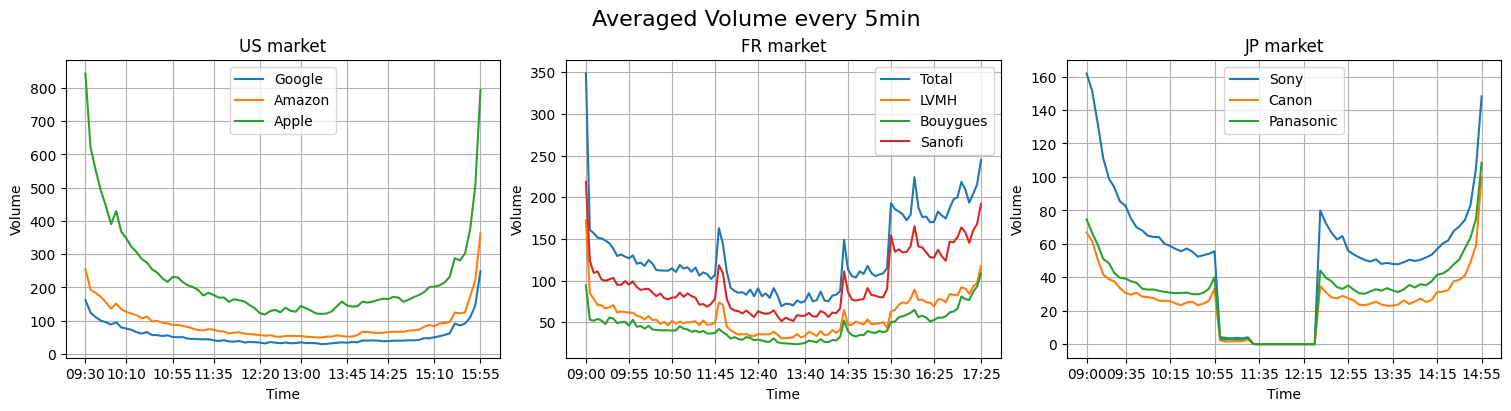

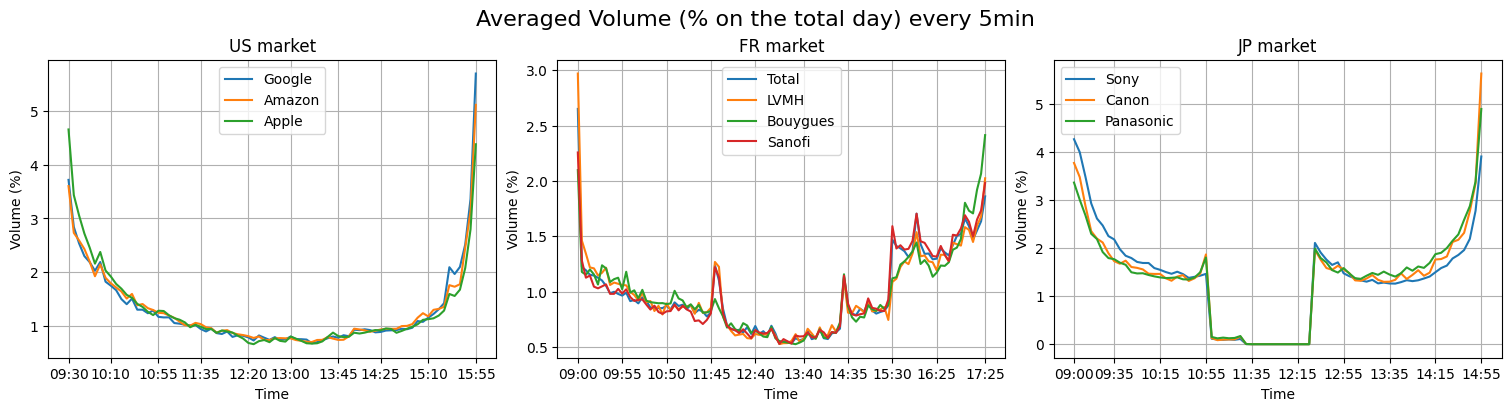

In [4]:
resample_volume(total_list,'5min', "Volume", titles, total_list_name, mean=False)
resample_volume(total_list,'5min', "Volume", titles, total_list_name, mean=True)

**Comments.**

**US Market:**

Most of the volume occurs at the beginning and the end of the trading day. This is linked to the fact that at the opening, the price is chosen to maximize the number of transactions. 

Just before the closing, people are reequilibrating their portfolio and particularly the physicial ETFs, explaining the high number of trades. Moreover, most of the informations came by the end of the day, enabling to make directionnal investment. 

**FR Market:**

This is the same as for the US market but we can see important pic at 12h00 (they do their trade before going to lunch), 14h30 (information from the US market), and 15h30 (opening of the US market).  

**JP Market:**

This is the same as the US market but we see the impact of the lunch pause (11h30 - 12h30h) leading to a drop of the volume an hour before the break and an important activity just after.  

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">2. Number of Trades Curves</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></iv>


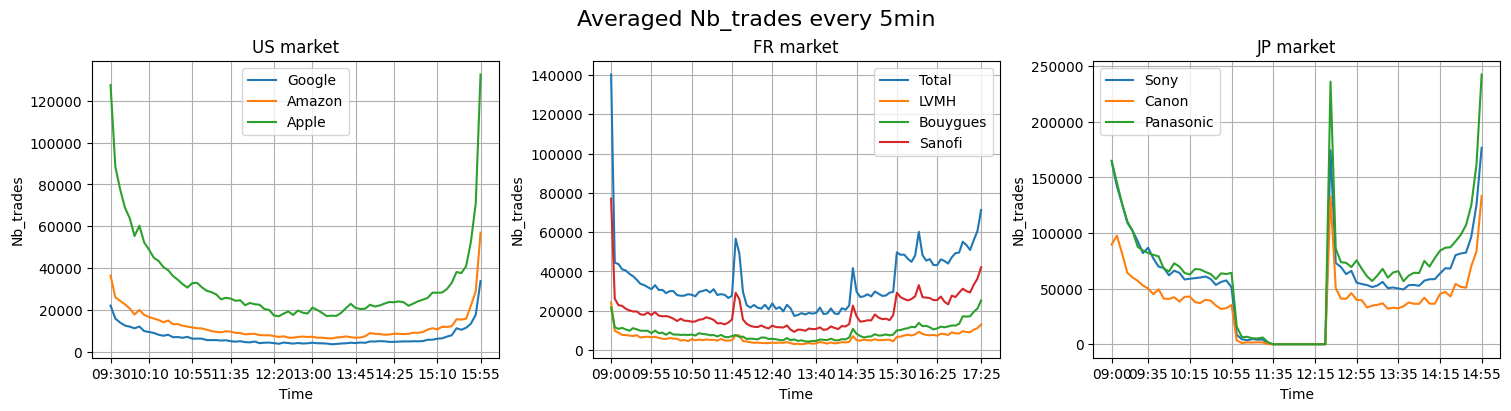

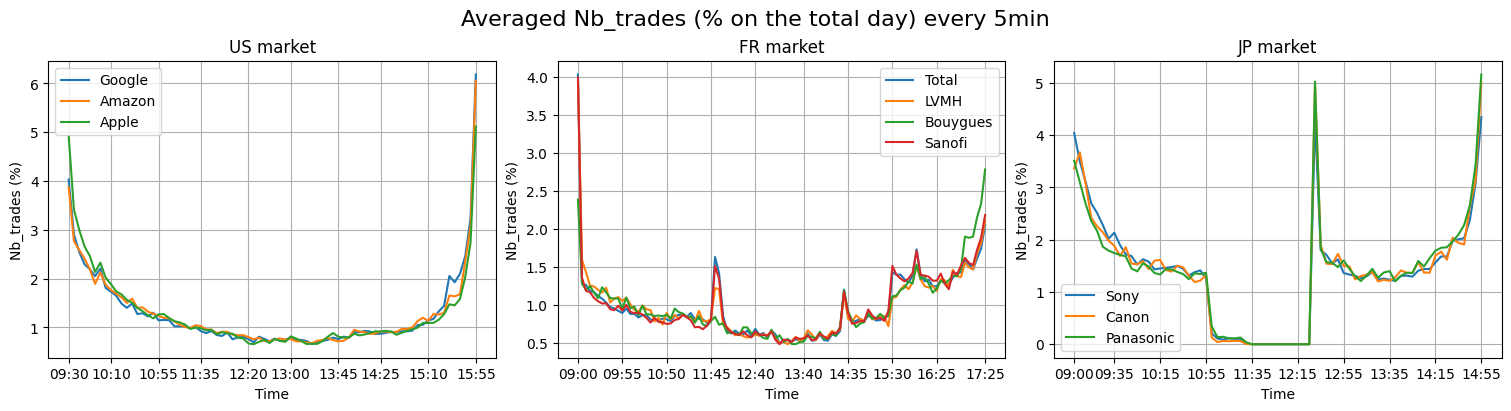

In [5]:
resample_volume(total_list,'5min', "Nb_trades", titles, total_list_name, mean=False)
resample_volume(total_list,'5min', "Nb_trades", titles, total_list_name, mean=True)

**Comments.**

**US Market:**

Same comments as for the volume. 

**FR Market:**

Same comments as for the volume. 

**JP Market:**

Same comments as for the volume. However, the number of trade is very important (nearly the same as the end of trading day)  just after the lunch break. Because the volume is not that high, we conclude that important trade in term of quantity are done after the lunch break. 

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">3. Turnover (Cash) Curves</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></iv>


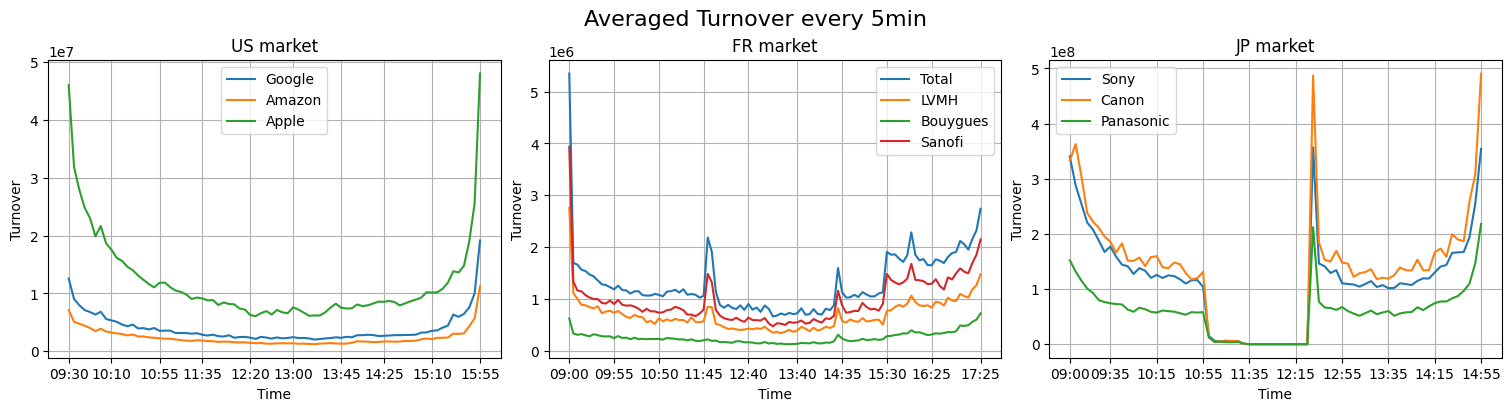

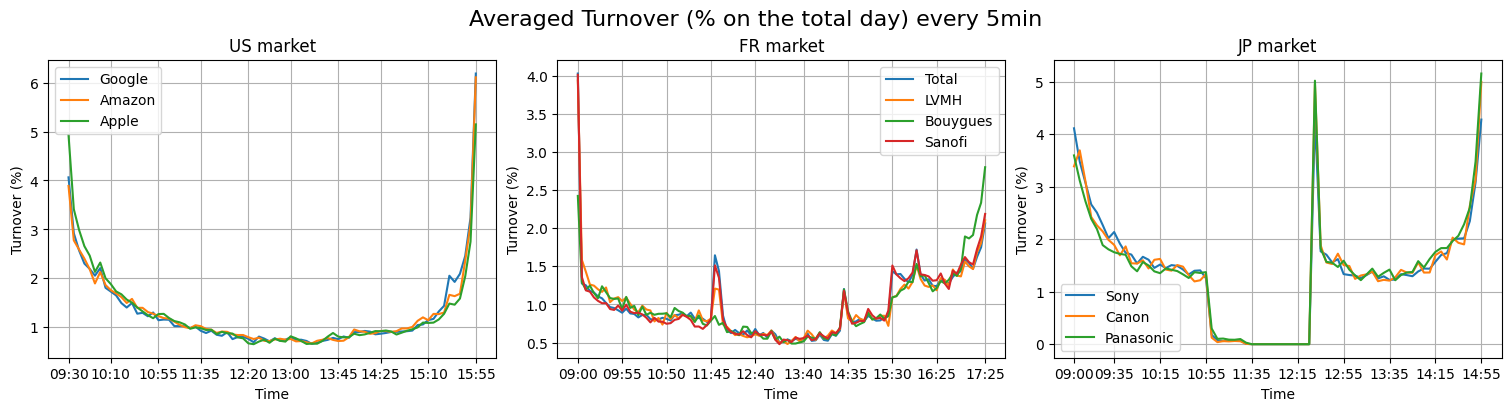

In [6]:
resample_volume(total_list,'5min', "Turnover", titles, total_list_name, mean=False)
resample_volume(total_list,'5min', "Turnover", titles, total_list_name, mean=True)

**Comments.**

**US Market:**

Same comments as for the volume. 

**FR Market:**

Same comments as for the volume. 

**JP Market:**

Same comments as for the number of trades. This reinforce the hypothesis that big trades are done just after the lunch break. 

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">4. Average Spread Curves</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></iv>


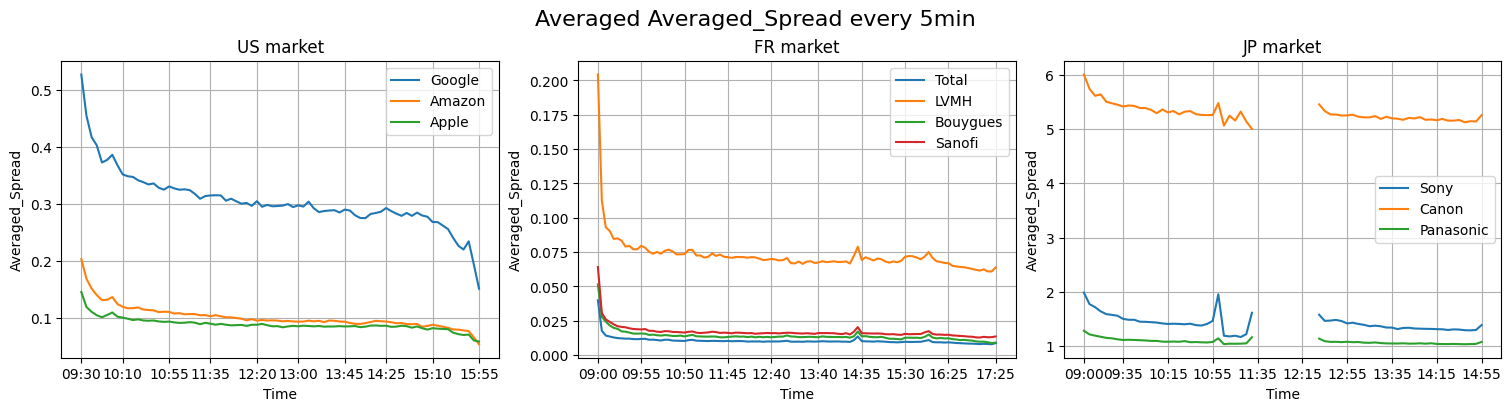

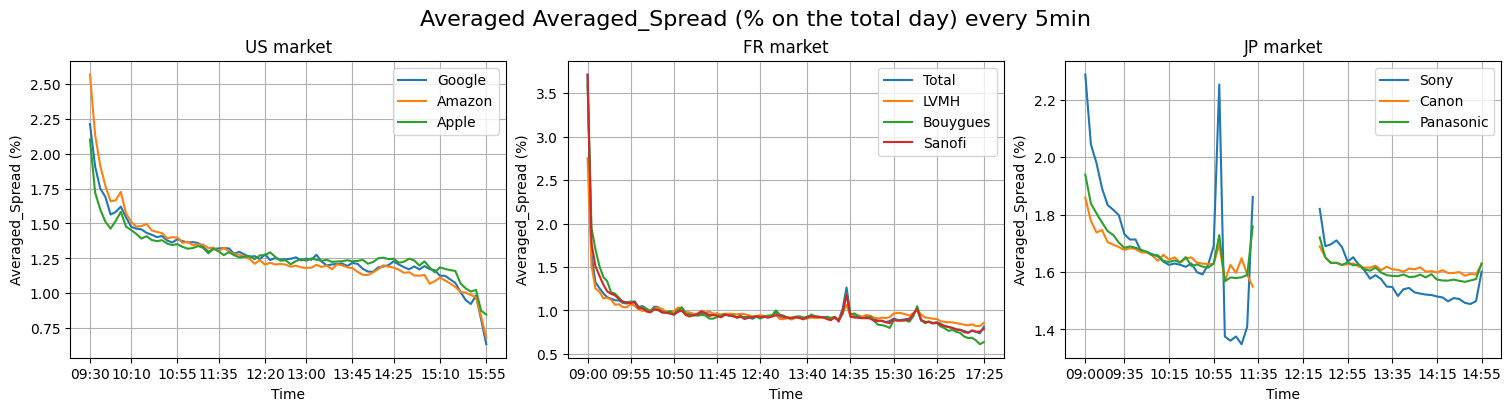

In [7]:
resample_volume(total_list,'5min', "Averaged_Spread", titles, total_list_name, mean=False)
resample_volume(total_list,'5min', "Averaged_Spread", titles, total_list_name, mean=True)

**Comments.**

**US Market:**

The spread is the highest at the beginning of the trading day and reduces itself progressively during the day, with a strong reduction at the end of the trading session. This represents the decrease of the incertitude about the future movements of the stocks during the day. 

At the end of the day, we know the stock's prices will not move a lot, most of the movements having taken palce during the day, leading to a lower spread. 

**FR Market:**

This is the same as for the US market but with a very strong decrease following the opening and a very slow decrease during the day with no particular drop at the end of the day. The spread at the beginning of the day is more important than in the US market and near to it at the end of the day. 

**JP Market:**

The curves are here very different. We sax an important decrease of the spread at the beginning of the day but with some rapid and strong increases and decreases just before the lunch break.

Just after the launch break, the sprea is higher thant at its beginning and slowly decrease until the end of the trading day, with a little increase just before the closing, showing the important trading activities taking place. 

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">5. Volatility Curves</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></iv>


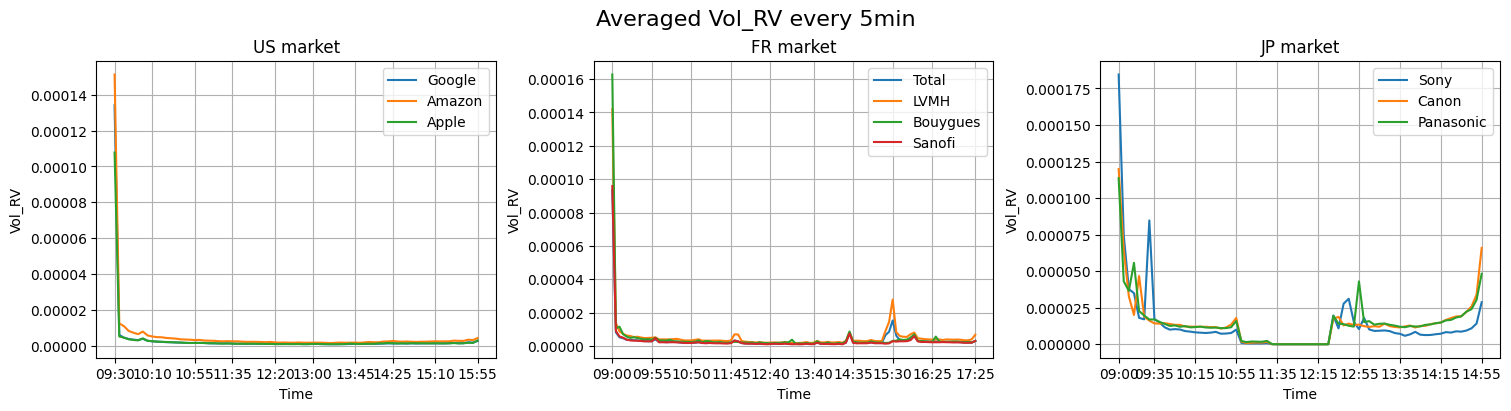

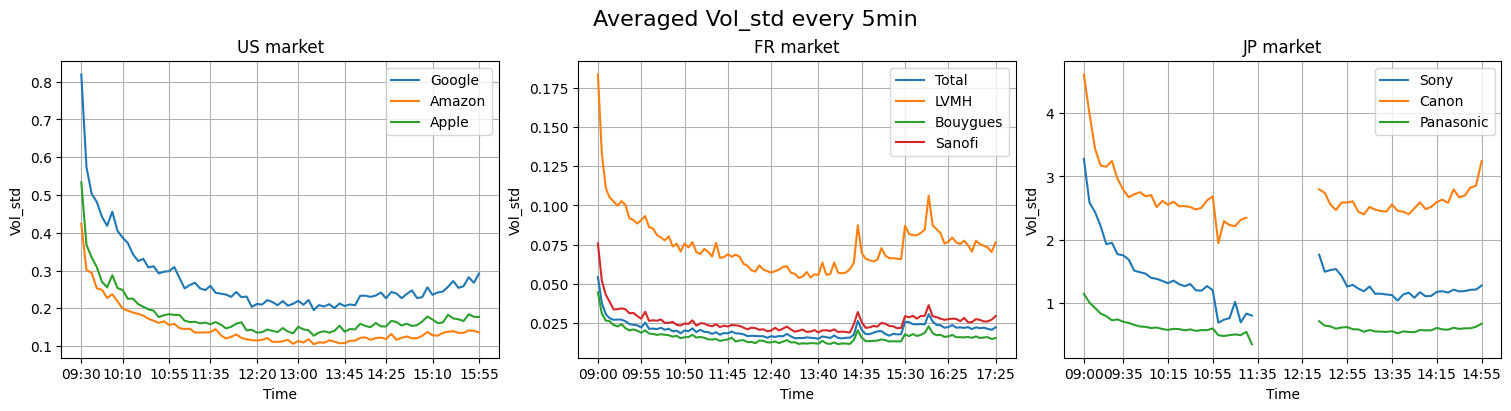

In [8]:
resample_volume(total_list,'5min', "Vol_RV", titles, total_list_name, mean=False)
resample_volume(total_list,'5min', "Vol_std", titles, total_list_name, mean=False)

**Comments.**

We used two measures to look at the volatility in order to well apprehend the tendance and have a better overview. 

**US Market:**

The volatility is very high at the beginning of the day (because of the number of transactions and the fixation of a stable price for the day) and reduces very slowly.  

**FR Market:**

The same as for the US market. 

We see pics at the same moments where we have an increase in the volume :  12h00 (they do their trade before going to lunch), 14h30 (information from the US market), and 15h30 (opening of the US market). 

**JP Market:**

The volatility begins high at the beginning of the day for the same reason as the US and FR markets. Moreover, , we see a little peak just after the lunch break as well as at the end of the trading day, because of the high number of transactions. 

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">6. Imbalance Curves (Unsigned $|Q_{ask}-Q_{bid}|/(Q_{ask}+Q_{bid})$ or Signed $(Q_{ask}-Q_{bid})/(Q_{ask}+Q_{bid})$)</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></iv>


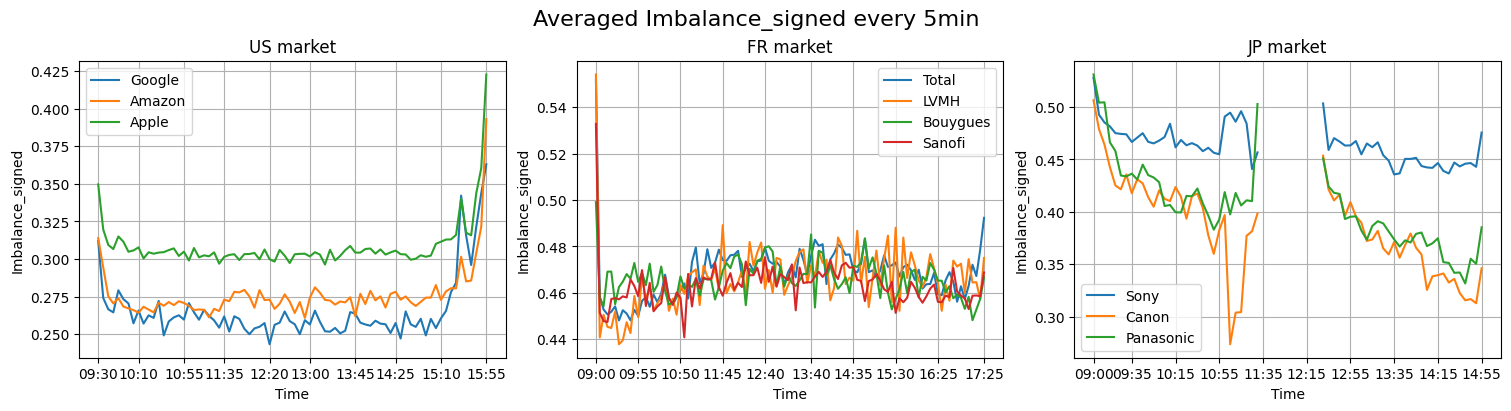

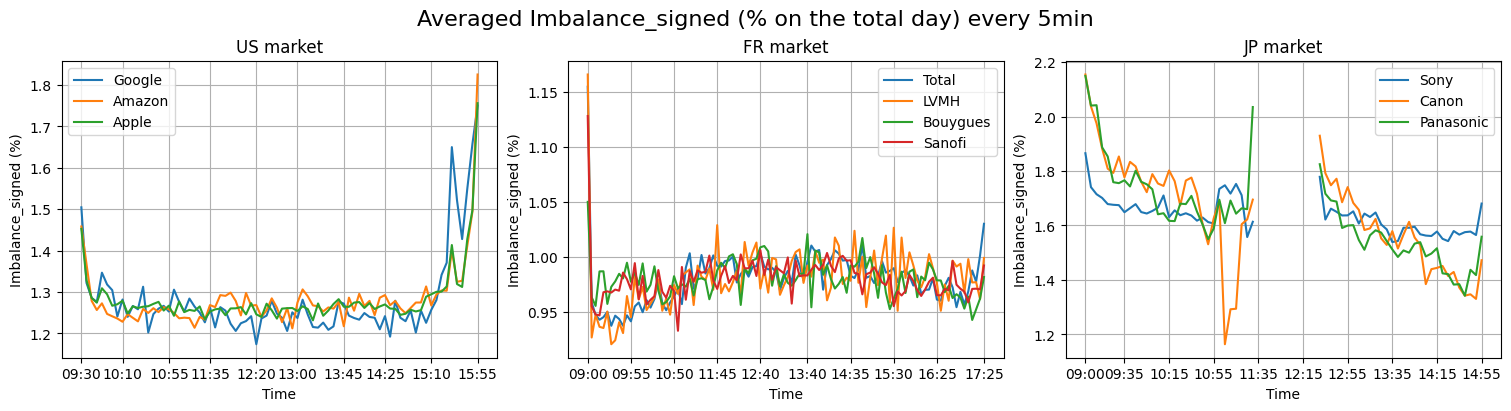

In [22]:
resample_volume(total_list,'5min', "Imbalance_signed", titles, total_list_name, mean=False)
resample_volume(total_list,'5min', "Imbalance_signed", titles, total_list_name, mean=True)

**Comments.**

**US Market:**

The imbalance signed begins very high at the beginning of the day and decrease all day with a strong increase (stronger than at the opening) at the end of the trading day due to the important volume taking places here leading the order book to go further within its tick values.  

**FR Market:**

The imbalance signed begins very high at the beginning of the day and decrease all day with a medium increase at the end of the trading day due to the important volume taking places here. 

We see pics at the same moments where we have an increase in the volume with a slow increase from 10h to 12h and a stagnation until 15h30, before a drop a a medium increase. 

**JP Market:**

Strong at the opening but we see the impact of the lunch pause (11h30 - 12h30h) leading to a drop of the imbalance an hour before the break. 

However, there is a very important decrease afeter the lunch break until the end of the day followed by a little increase. 

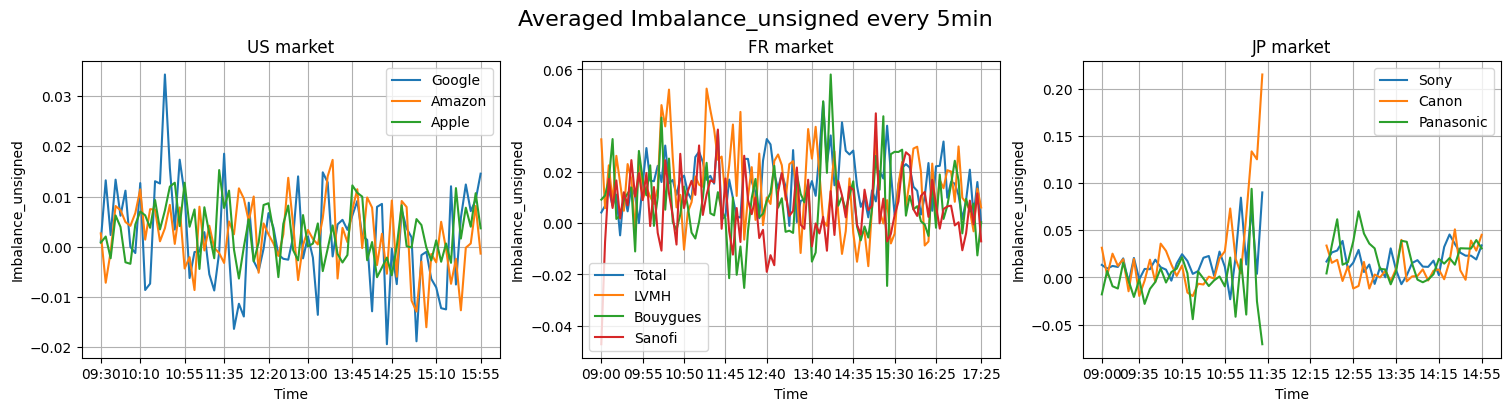

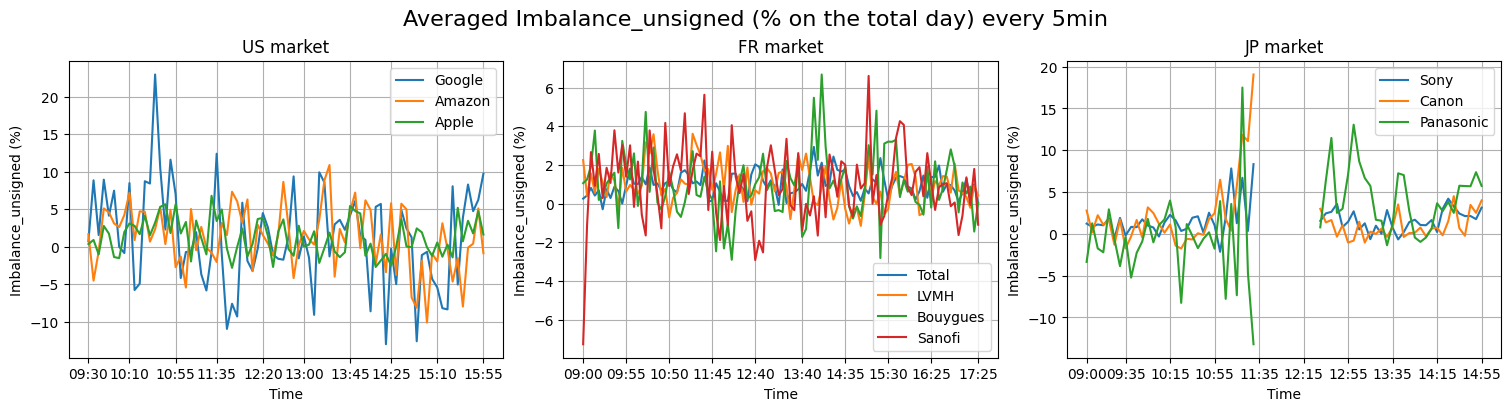

In [23]:
resample_volume(total_list,'5min', "Imbalance_unsigned", titles, total_list_name, mean=False)
resample_volume(total_list,'5min', "Imbalance_unsigned", titles, total_list_name, mean=True)

**Comments.**

A positive unsigned imbalance means there is the market is more oriented to sell rathern buy. The contrary can be applied for negative signed imbalance. 

**US Market:**

The imbalance unsigned stay in average at 1 tick (0.005) during all the trading day with a lot of strong variation during the day, accelerating a little at the end of the day. The fluctuations vary in intensity according to the stock we are looking at, showing more or less activity on this stock. 

The unsigned imbalance is nearly always a little above 0 which is normal, the best ask being a little higher than the best bid (spread bid-ask)

**FR Market:**

There is a very strong buy phenomena at the begining of the day and during all the trading day, in average at one tick (0.01) with as well strong variations for some specific stocks. 

**JP Market:**

The day begins very slowly. However, we see a very strong activity just before the lunch break, depending on the stock, showing a lot of trades at this period. The signed imbalance is then on average at one tick until the end of the day with some variation, nearly always positive ones. 

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">7. Curves of Quantities at Best Limits $Q_{ask} + Q_{bid}$</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></iv>


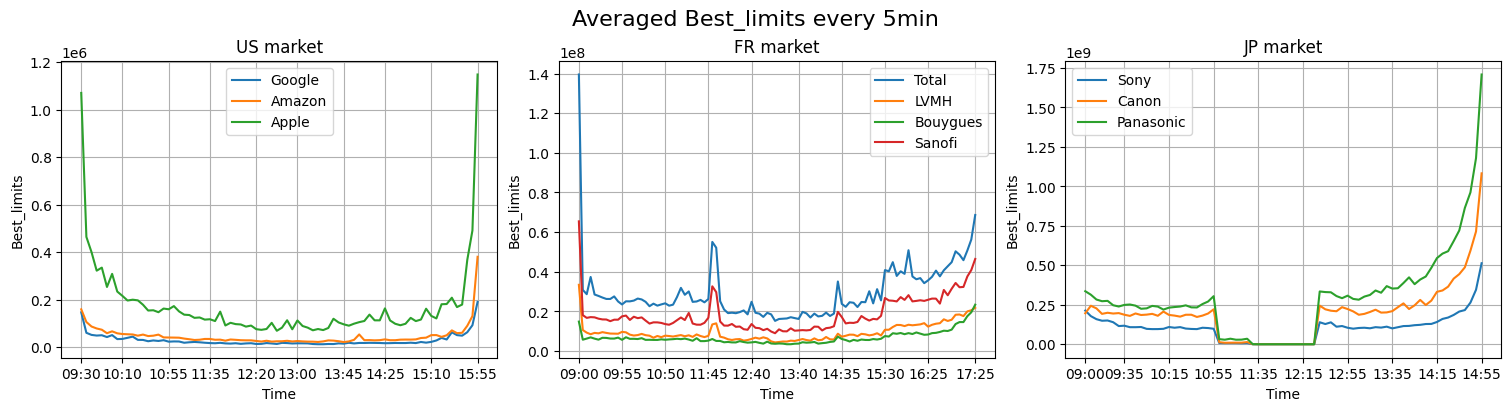

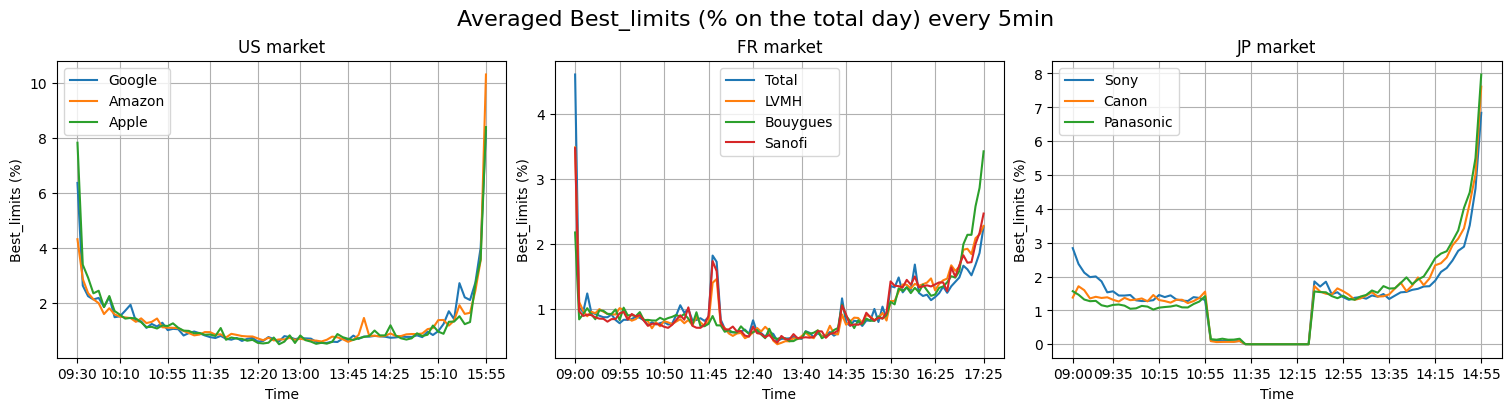

In [15]:
resample_volume(total_list,'5min', "Best_limits", titles, total_list_name, mean=False)
resample_volume(total_list,'5min', "Best_limits", titles, total_list_name, mean=True)

**Comments.**

**US Market:**

The best limits, begins very high at the beginning of the day and decrease until the middle of the day and increases until the end of the day to finally reach higher level than at the beginning of the day. 

**FR Market:**

The best limits drops significantly at the beginning of the day until the middle of the day and increases after.

We see pics at the same moments where we have an increase in the volume :  12h00 (they do their trade before going to lunch), 14h30 (information from the US market), and 15h30 (opening of the US market). 

**JP Market:**

This is the same as the US market but we see the impact of the lunch pause (11h30 - 12h30h) leading to a drop of the best limits an hour before the break. 

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">III. Relationship Between Daily Indicators</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></iv>


You will now examine the relationship between certain daily indicators using linear regressions:
* the relationship between volume and number of trades,  
* between turnover and number of trades,  
* between volatility per trade and the bid-ask spread.

As before, you will create one plot per exchange with the 3 or 4 assets from each.  
You will then comment on the results obtained for each of these relationhips.


In [12]:
# Function to plot a linear regression between two indicators. 
# Enables to do several plot with 5 per row maximim
def plot_regression(dfs_list,period, data_type_list, titles, stock_names_list, mean=False):

    # Maximum of 5 graphs per row 
    max_cols = 5
    cols = len(data_type_list)  
    max = 0
    for idx,(dfs, stock_names,title) in enumerate(zip(dfs_list,stock_names_list, titles)):

        # Dynamically create the plots for each sublist in the given lists
        num_relations = len(data_type_list)
        rows = (num_relations // max_cols) + (num_relations % max_cols > 0)
        fig, axes = plt.subplots(rows, max_cols, figsize=(5 * max_cols, 4 * rows), constrained_layout=True)
        
        if rows == 1: 
            axes = np.array([axes])  
        axes = axes.flatten()
        
        for subplot_idx, data_type in enumerate(data_type_list) : 
            ax = axes[subplot_idx]
        
            for df, stock_name in zip(dfs,stock_names)  : 

                # For each dataframe within the sublist, we compute our indicators and we do not groupby to have the average per period on a day but we keep the data per period for each day
                data_1 = return_worked_column (df, period, data_type[0], condense = False)
                data_2 = return_worked_column (df,period, data_type[1], condense = False)

                # We clean our dataset
                data_1 = data_1.fillna(0)
                data_2 = data_2.fillna(0)

                # If we want to take our data in an average point of view
                if mean : 
                    data_1 = (data_1 / data_1.sum()) * 100
                    data_2 = (data_2 / data_2.sum()) * 100

                # We compute our regressin and predicted value
                X = data_1.values.reshape(-1, 1)  
                Y = data_2.values.reshape(-1, 1)  

                model = LinearRegression()
                model.fit(X,Y)
                X_range = np.linspace(0, X.max(), 100).reshape(-1, 1)
                Y_pred = model.predict(X_range)

                # We plot our points and our regression function
                ax.scatter(X,Y,label = stock_name, marker = ".", alpha = 0.3)
                ax.plot(X_range, Y_pred, label = f"Linear Regression for {stock_name}")  
       
            ax.set_xlabel(data_type[0])
            ax.set_ylabel(data_type[1])
            ax.legend(fontsize='small')
            ax.grid()
            ax.set_title(f"{title} - {data_type[1]} vs. {data_type[0]}")

        # We dynamically delete the non used plots
        for j in range(num_relations, len(axes)):
            fig.delaxes(axes[j])          
      
        plt.show()


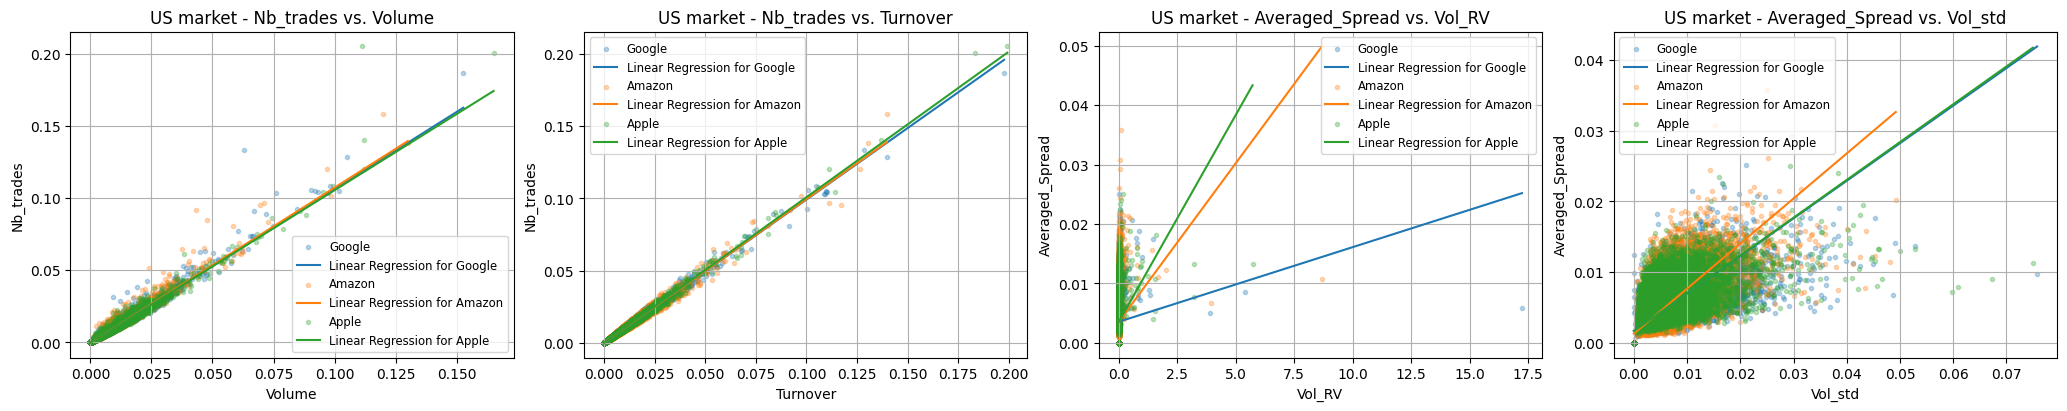

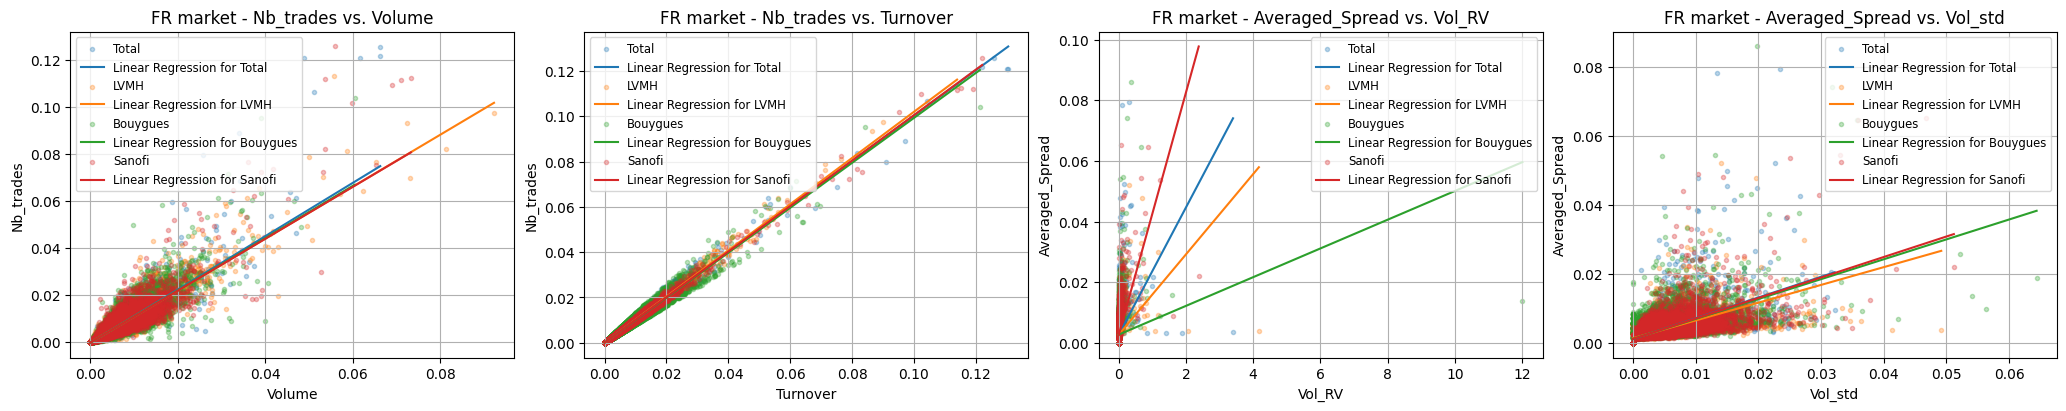

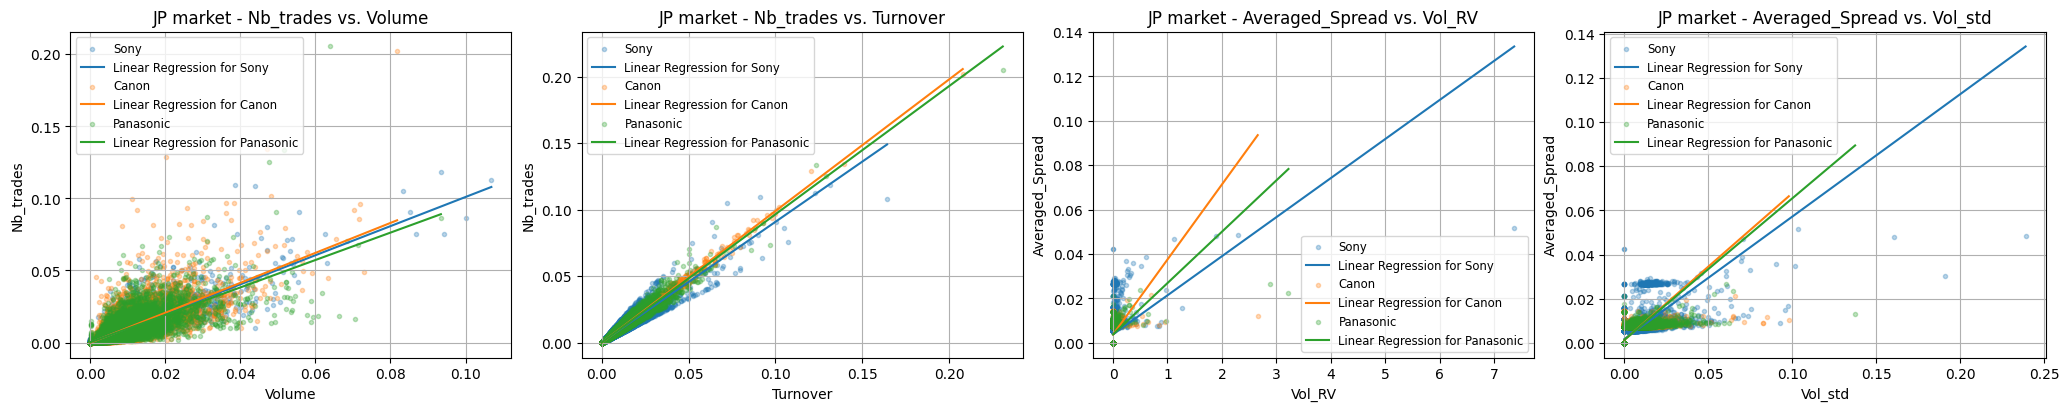

In [29]:
liste = [["Volume", "Nb_trades"], ["Turnover", "Nb_trades"], ["Vol_RV","Averaged_Spread"], ["Vol_std","Averaged_Spread"] ]
plot_regression(total_list,"5min", liste, titles, total_list_name, mean=True)

**Comments.**

**Important:** We are looking at the % of the total volum of both axes to have a good understanding of the relative effects.

#### Volume vs Number of trades

**US Market:**

Nearly a perfect linear relationship with a coeficient of 0.5 adn some outliers always above the linear relationship. 

**FR Market:**

A linear relationship in tendancy by with more outliers, most of them above the curve when the volume (>4% of the volume within the total day) and a kind of centered elllipse around the linear cruve from 0 to 4% of the trade. 

The coefficient of the regression is near 1 i.e the identity function (the % of volumne on the day is nearly the % of trades on the day). 

**JP Market:**

This is the same as for the French market with the ellipse until 4% being a little stepped above the linear curve. The coefficient if here near 1 as well. 

#### Turnover vs Number of trades

**US Market:**

This is nearly a perfect linear relationship with a coefficient near 1. 

**FR Market:**

Same as for the US market with a little more outliers but still close to the linear curve. 

**JP Market:**

Same as for the US market with a little ellipse centered around the curve for the first 5% and some coefficient nearly around 1 depending of the looked stock. 


#### Volatility vs Averaged spread

**We will only comment the volatility with the standard deviation as the log return approach is not exploitable and would require a speciic adaptation of the function. Because the tendancies are quit similar, comment only one linear relationship would be enough**

**US Market:**

Here we can see thant the linear relationship is not very appropriate. Indeed, most of the volatility, happens when the average_spread is not very high i.e when there is a lot of trades on the underlying.

When the averaged_spread is high, the volatility does not obligatory increase but in the contrary, the volatility can sometimes be very important for trade with a low average_spread (showing big orders eatings a lot of ticks and therefore changing the price a lot). 

**FR Market:**

The linear relation is also not appropiate here, with the same observations as for the US market. However, the average spread is higher in general (twice) the amount he is in the US market showing less liquidity for the stocks. 

Moroever, there are a significant amount of trades with high averaged spread happing without causing a lot of liquidity, highlighting also the lack of liquidity. We also have outliers with high volatility and low averaged spread, more tha in the US market, showing less important orders. 

**JP Market:**

The average_spread imply more volatility (twice) than for the US or FR market. However, we have very few outliers and the 2% averaged spread explains between 3-4% of the volatility each time. There are almost no trade with low volatility and high averaged spread, but an important quantity in the other hand, showing the presence of important orders/ 

We also plot without the average effect to have a better overview. We will however have the same tendancies but the absolue amount would give some more precise information. 

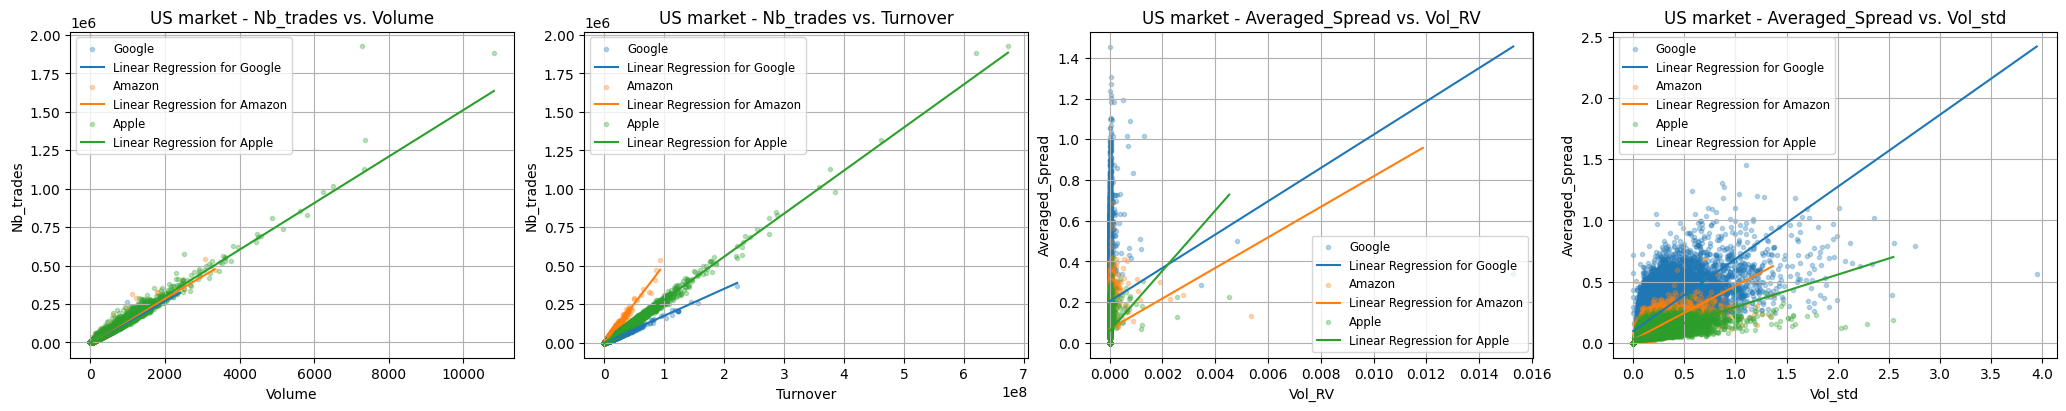

C:\Users\const\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


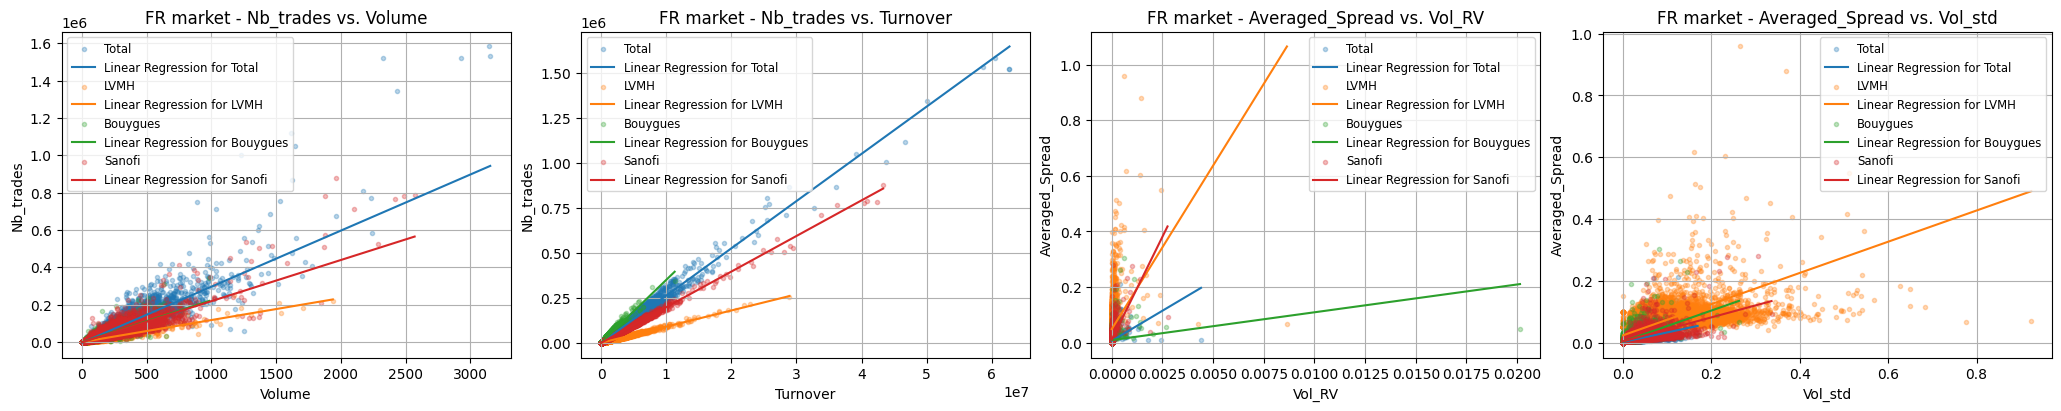

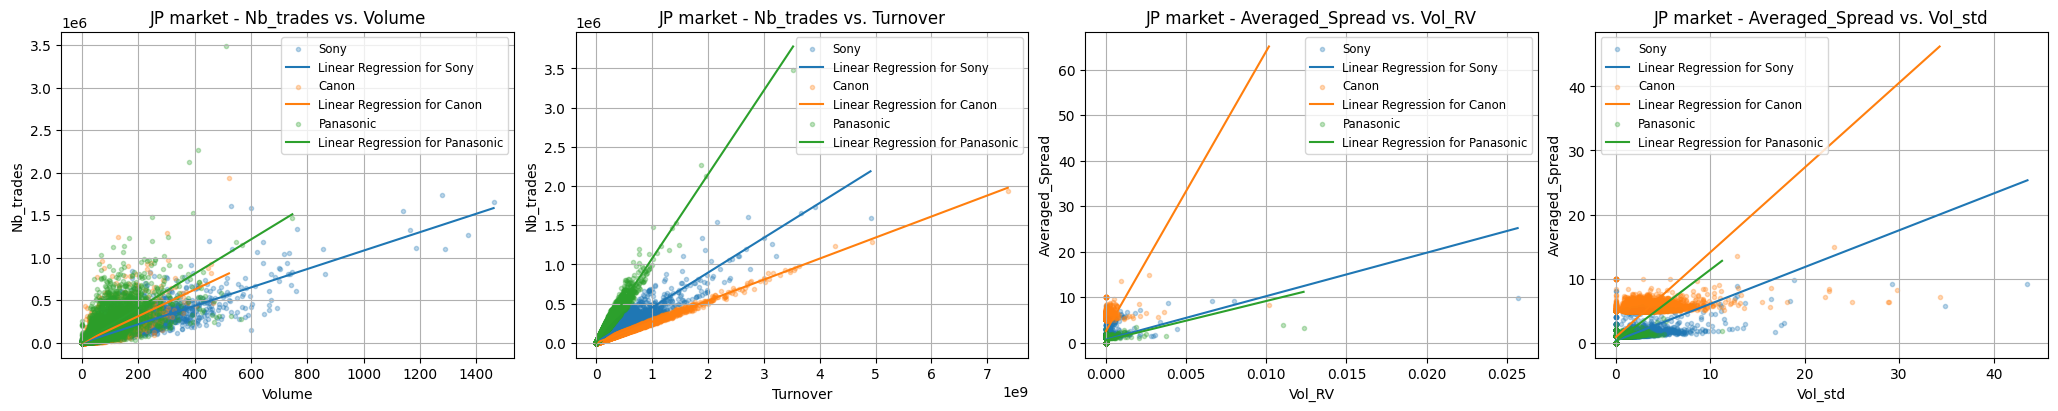

In [30]:
plot_regression(total_list,"5min", liste, titles, total_list_name, mean=False)